In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import dismech_jax as djx


# =========================================================
# Coordinate-based energy model: E = NN(q - q_ref)
# =========================================================
class MLP_Energy_DOF(eqx.Module):
    ws: tuple[jax.Array, ...]
    bs: tuple[jax.Array, ...]
    k0_raw: jax.Array

    def __init__(
        self,
        key,
        in_size=2,
        hidden_sizes=(10,),
        K_initial=0.1,
        weight_scale=1.0,
    ):
        """
        Coordinate-based neural energy model.

        Energy = 0.5 * K0 * ||q_rel||^2 + MLP(q_rel)

        q_rel = q - q_ref

        Args:
            in_size: input dimension (2 here, since q = [x_left, x_right])
            hidden_sizes: tuple of hidden layer sizes
            K_initial: initial quadratic baseline coefficient
            weight_scale: scale for weight initialization
        """
        sizes = (in_size,) + hidden_sizes + (1,)
        keys = jax.random.split(key, len(sizes) - 1)

        ws = []
        bs = []
        for k, din, dout in zip(keys, sizes[:-1], sizes[1:]):
            w = jax.random.normal(k, (dout, din)) * weight_scale
            b = jnp.zeros((dout,))
            ws.append(w)
            bs.append(b)

        self.ws = tuple(ws)
        self.bs = tuple(bs)
        self.k0_raw = jnp.array(K_initial)

    def mlp(self, x):
        h = x
        for w, b in zip(self.ws[:-1], self.bs[:-1]):
            h = jax.nn.softplus(w @ h + b)
        out = self.ws[-1] @ h + self.bs[-1]
        return out[0]

    def __call__(self, q_rel):
        k0 = jax.nn.softplus(self.k0_raw)
        baseline = 0.5 * k0 * jnp.sum(q_rel**2)
        correction = self.mlp(q_rel)
        return correction


# =========================================================
# 2-node displacement-controlled toy system
# =========================================================
class Slinky1D(djx.System):
    """Simple 2-node 1D spring under exact displacement control."""

    l_k: jax.Array
    x_left: jax.Array
    q_ref: jax.Array

    def get_q(self, disp: jax.Array, q0: jax.Array) -> jax.Array:
        """
        disp is the exact prescribed position of the pulled node.

        Left node is fixed at x_left.
        Right node is prescribed directly to disp.
        """
        q = q0.at[0].set(self.x_left)
        q = q.at[1].set(disp)
        return q

    def get_eps(self, q: jax.Array) -> jax.Array:
        return (q[1] - q[0]) / self.l_k - 1.0

    def get_q_rel(self, q: jax.Array) -> jax.Array:
        """Coordinates relative to reference configuration."""
        return q - self.q_ref

    # def get_E(
    #     self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    # ) -> jax.Array:
    #     q_rel = self.get_q_rel(q)
    #     return model(q_rel)

    def get_E(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        return model(q)

    def get_F(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # No free DOFs in this fully prescribed toy problem.
        return jnp.zeros_like(q)

    def get_H(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # Dummy Hessian for API compatibility.
        return jnp.eye(q.shape[0])

    def get_reaction_force(
        self, disp: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        """
        Reaction force at the pulled (right) node.

        If your measured force uses the opposite sign convention,
        flip the sign here.
        """
        dEdq = jax.grad(self.get_E, argnums=1)(disp, q, model, aux)
        return dEdq[1]


# =========================================================
# Optional: shift measured forces so reference force is zero
# =========================================================
def normalize_force_to_zero_at_reference(F):
    return F - F[0]


# =========================================================
# Load data from saved format with exact displacements
# =========================================================
data = np.load("experiment_data/pulling_phase_data.npz")

force_truth = jnp.array(data["F"])         # shape (N,)
disps = jnp.array(data["disps"])           # exact pulled-node positions
initial_last_node_x = float(data["initial_last_node_x"])

# Optional force normalization
force_truth = normalize_force_to_zero_at_reference(force_truth)

num_steps = force_truth.shape[0]

# Two-node system:
# node 0 fixed at x = 0
# node 1 starts at initial_last_node_x
x_left = 0.0
q0 = jnp.array([x_left, initial_last_node_x])

# Initial rest length
l_k0 = q0[1] - q0[0]

slinky = Slinky1D(
    l_k=jnp.array(l_k0),
    x_left=jnp.array(x_left),
    q_ref=q0,
)

model = MLP_Energy_DOF(
    jax.random.PRNGKey(42),
    in_size=2,                 # q_rel = [x_left - x_left_ref, x_right - x_right_ref]
    hidden_sizes=(10,),
    K_initial=0.1,
    weight_scale=1.0,
)


# =========================================================
# Train/test split using displacement directly
# =========================================================
disp_min = disps.min()
disp_max = disps.max()

test_range = (
    disp_min + 0.2 * (disp_max - disp_min),
    disp_min + 0.8 * (disp_max - disp_min),
)

train_mask = (disps <= test_range[0]) | (disps >= test_range[1])
test_mask = (disps > test_range[0]) & (disps < test_range[1])

train_disps = disps[train_mask]
train_force_truth = force_truth[train_mask]

test_disps = disps[test_mask]
test_force_truth = force_truth[test_mask]

print("Num total samples:", num_steps)
print("Num train samples:", train_disps.shape[0])
print("Num test samples :", test_disps.shape[0])
print("Initial pulled-node x:", initial_last_node_x)
print("Rest length l_k0     :", l_k0)


# =========================================================
# Prediction: exact displacement -> prescribed q -> reaction force
# =========================================================
def predict_force(model, disp_vals):
    def one_force(disp):
        q = slinky.get_q(disp, q0)
        return slinky.get_reaction_force(disp, q, model, None)

    return jax.vmap(one_force)(disp_vals)


# =========================================================
# Loss
# =========================================================
def train_loss(model):
    pred_force = predict_force(model, train_disps)
    return jnp.mean((train_force_truth - pred_force) ** 2)


def test_loss(model):
    pred_force = predict_force(model, test_disps)
    return jnp.mean((test_force_truth - pred_force) ** 2)


# =========================================================
# Optimizer
# =========================================================
lr = 1e-2
schedule = optax.piecewise_constant_schedule(
    init_value=lr,
    boundaries_and_scales={7500: 0.1},
)
optimizer = optax.adam(learning_rate=schedule)

opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(carry, _):
    model, opt_state = carry
    loss_val, grads = eqx.filter_value_and_grad(train_loss)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt_state), loss_val


num_epochs = 10000
log_freq = 500


def train_loop(model, opt_state):
    def scan_fn(carry, i):
        next_carry, loss_val = train_step(carry, None)

        def log_loss(_):
            current_model, _ = next_carry
            t_loss = test_loss(current_model)
            jax.debug.print(
                "Epoch: {x}, Train Loss: {y}, Test Loss: {z}",
                x=i,
                y=loss_val,
                z=t_loss,
            )

        jax.lax.cond(i % log_freq == 0, log_loss, lambda _: None, operand=None)
        return next_carry, loss_val

    (final_model, final_opt_state), loss_history = jax.lax.scan(
        scan_fn, (model, opt_state), jnp.arange(num_epochs + 1)
    )
    return final_model, loss_history


final_model, loss_history = train_loop(model, opt_state)


# =========================================================
# Evaluate on full displacement trajectory
# =========================================================
pred_full_force = predict_force(final_model, disps)

train_mse = jnp.mean((force_truth[train_mask] - pred_full_force[train_mask]) ** 2)
test_mse = jnp.mean((force_truth[test_mask] - pred_full_force[test_mask]) ** 2)

print("Final train force MSE:", train_mse)
print("Final test  force MSE:", test_mse)


# =========================================================
# Save results
# =========================================================
np.savez(
    "coordinate_based_ablation_results.npz",
    disps=np.array(disps),
    force_truth=np.array(force_truth),
    pred_force=np.array(pred_full_force),
    train_mask=np.array(train_mask),
    test_mask=np.array(test_mask),
    loss_history=np.array(loss_history),
)

Num total samples: 179
Num train samples: 79
Num test samples : 100
Initial pulled-node x: 0.2
Rest length l_k0     : 0.2
Epoch: 0, Train Loss: 23.580181121826172, Test Loss: 1.9189265966415405
Epoch: 500, Train Loss: 1.901376485824585, Test Loss: 1.9354724884033203
Epoch: 1000, Train Loss: 1.2633734941482544, Test Loss: 0.6401882171630859
Epoch: 1500, Train Loss: 0.70032799243927, Test Loss: 0.14639216661453247
Epoch: 2000, Train Loss: 0.34771227836608887, Test Loss: 0.1263190358877182
Epoch: 2500, Train Loss: 0.17009992897510529, Test Loss: 0.20992085337638855
Epoch: 3000, Train Loss: 0.09113582223653793, Test Loss: 0.29961228370666504
Epoch: 3500, Train Loss: 0.06356024742126465, Test Loss: 0.38558322191238403
Epoch: 4000, Train Loss: 0.05752381309866905, Test Loss: 0.40966323018074036
Epoch: 4500, Train Loss: 0.05477452278137207, Test Loss: 0.3896876573562622
Epoch: 5000, Train Loss: 0.05284750834107399, Test Loss: 0.3701437711715698
Epoch: 5500, Train Loss: 0.05166945233941078, Te

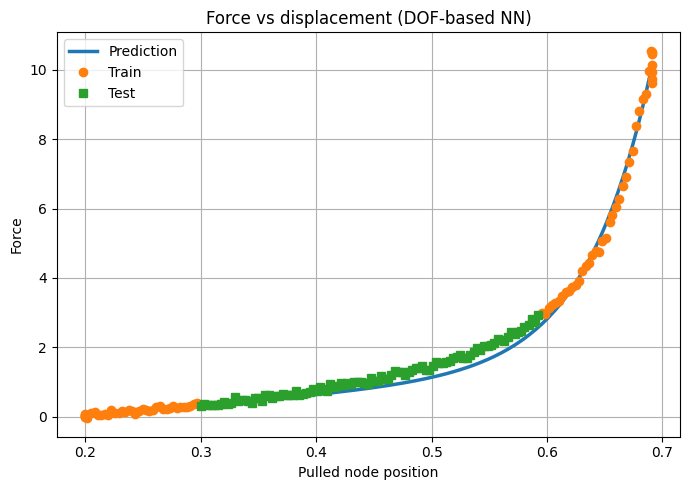

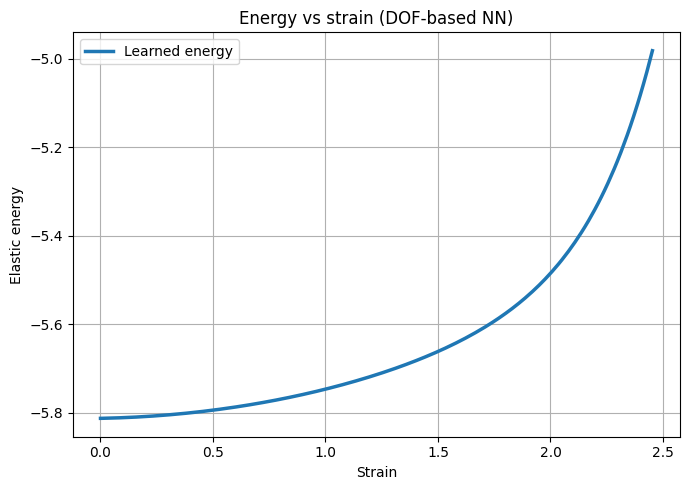

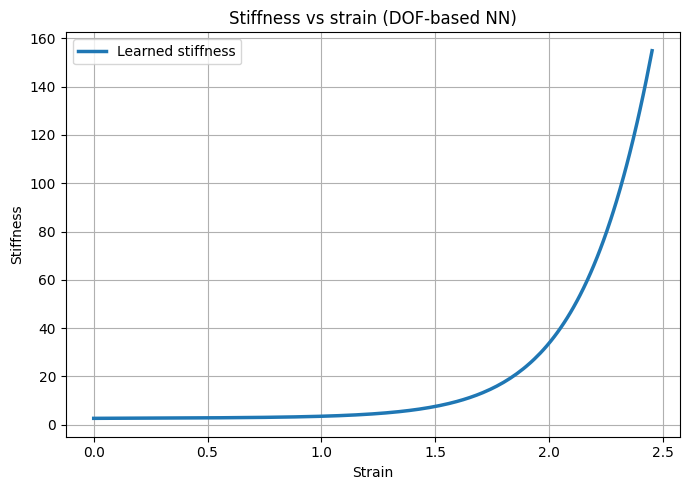

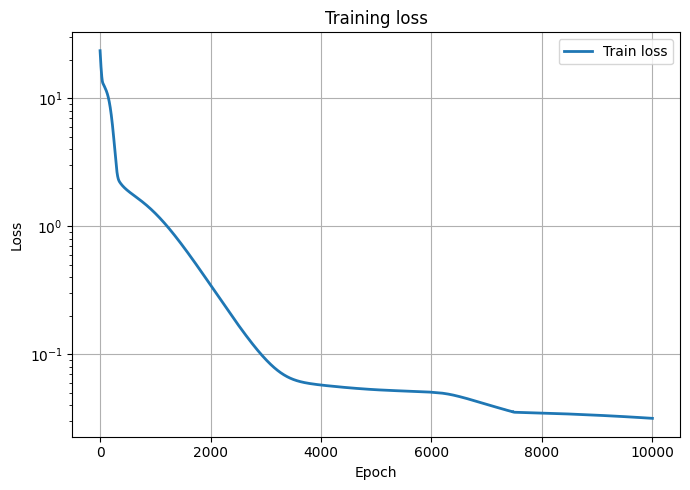

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

# =========================================================
# Convert to numpy
# =========================================================
disps_np = np.array(disps)
force_truth_np = np.array(force_truth)
pred_full_force_np = np.array(pred_full_force)

train_mask_np = np.array(train_mask)
test_mask_np = np.array(test_mask)


# =========================================================
# Sort everything for clean curves
# =========================================================
sort_idx_disp = np.argsort(disps_np)

disps_sorted = disps_np[sort_idx_disp]
pred_sorted = pred_full_force_np[sort_idx_disp]
force_sorted = force_truth_np[sort_idx_disp]


# =========================================================
# 1. Force vs displacement (clean publication version)
# =========================================================
plt.figure(figsize=(7, 5))

# Prediction curve
plt.plot(disps_sorted, pred_sorted, "-", linewidth=2.5, label="Prediction")

# Train samples
plt.plot(
    disps_np[train_mask_np],
    force_truth_np[train_mask_np],
    "o",
    markersize=6,
    label="Train",
)

# Test samples
plt.plot(
    disps_np[test_mask_np],
    force_truth_np[test_mask_np],
    "s",
    markersize=6,
    label="Test",
)

plt.xlabel("Pulled node position")
plt.ylabel("Force")
plt.title("Force vs displacement (DOF-based NN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 2. Build q and strain
# =========================================================
qs = jax.vmap(lambda d: slinky.get_q(d, q0))(disps)
strains = jax.vmap(slinky.get_eps)(qs)

strains_np = np.array(strains)

# Sort by strain
sort_idx_strain = np.argsort(strains_np)
strains_sorted = strains_np[sort_idx_strain]


# =========================================================
# 3. Energy vs strain (IMPORTANT FIX)
# =========================================================
def energy_from_disp(d):
    q = slinky.get_q(d, q0)
    return slinky.get_E(d, q, final_model, None)

Energy = jax.vmap(energy_from_disp)(disps)
Energy_np = np.array(Energy)

Energy_sorted = Energy_np[sort_idx_strain]

plt.figure(figsize=(7, 5))
plt.plot(
    strains_sorted,
    Energy_sorted,
    linewidth=2.5,
    label="Learned energy",
)

plt.xlabel("Strain")
plt.ylabel("Elastic energy")
plt.title("Energy vs strain (DOF-based NN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 4. Stiffness vs strain (CORRECT for DOF-based model)
# =========================================================
# Force = dE/dq_right
# Stiffness = dF/dq_right = d²E/dq_right²

def energy_wrt_q(q):
    return final_model(q)

def force_wrt_q(q):
    dEdq = jax.grad(energy_wrt_q)(q)
    return dEdq[1]

def stiffness_wrt_q(q):
    return jax.grad(force_wrt_q)(q)[1]

# Compute stiffness along trajectory
stiffness = jax.vmap(lambda d: stiffness_wrt_q(slinky.get_q(d, q0)))(disps)
stiffness_np = np.array(stiffness)

stiffness_sorted = stiffness_np[sort_idx_strain]

plt.figure(figsize=(7, 5))
plt.plot(
    strains_sorted,
    stiffness_sorted,
    linewidth=2.5,
    label="Learned stiffness",
)

plt.xlabel("Strain")
plt.ylabel("Stiffness")
plt.title("Stiffness vs strain (DOF-based NN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 5. Training loss history
# =========================================================
loss_history_np = np.array(loss_history)

plt.figure(figsize=(7, 5))
plt.plot(loss_history_np, linewidth=2, label="Train loss")
plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
strain_np = np.array(strains)

def get_K_scalar(eps_scalar):
    return final_model.get_K(jnp.array([eps_scalar]))

def get_delta_scalar(eps_scalar):
    return final_model.K_mlp(jnp.array([eps_scalar]))

delta_vals = jax.vmap(get_delta_scalar)(strains)
K_total_vals = jax.vmap(get_K_scalar)(strains)

K0_val = final_model.K_baseline()
K0_vals = jnp.ones_like(K_total_vals) * K0_val

K_total_np = np.array(K_total_vals)
delta_np = np.array(delta_vals)
K0_np = np.array(K0_vals)

idx = np.argsort(strain_np)

strain_np = strain_np[idx]
K_total_np = K_total_np[idx]
delta_np = delta_np[idx]
K0_np = K0_np[idx]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------
# (a) Baseline vs total stiffness
# -----------------------------------
axs[0].plot(strain_np, K_total_np, linewidth=2, label="Total K(ε)")
axs[0].plot(strain_np, K0_np, "--", linewidth=2, label="Baseline K0")
axs[0].set_xlabel("Strain")
axs[0].set_ylabel("Stiffness")
axs[0].set_title("Baseline vs total stiffness")
axs[0].legend()
axs[0].grid(True)

# -----------------------------------
# (b) MLP correction
# -----------------------------------
axs[1].plot(strain_np, delta_np, linewidth=2, label="MLP correction (raw)")
axs[1].set_xlabel("Strain")
axs[1].set_ylabel("ΔK (before softplus)")
axs[1].set_title("MLP correction vs strain")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

AttributeError: 'MLP_Energy_DOF' object has no attribute 'K_mlp'